In [1]:
########## import some useful package ##########

import time
t1 = time.time()

import sys
sys.path.insert(0, '/root/work/Papers')
import paper_style as ps
ps.set_style()  # 套用論文的全局字體與樣式設定
from paper_style import hep_tag

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import ripser
import persim

In [2]:
########## read the data ##########

processes = ["hhvv", "hhmumu", "jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
event_type = [str(i)+"_500K" for i in processes]

BR_hbb = 0.5824
Xsection = [5.6572451e-02*BR_hbb*BR_hbb, 4.758146e-03*BR_hbb*BR_hbb, 1.345440e+01, 4.423700e+00, 2.325600e+00, 1.507183e+02, 1.223107e+01, 9.617100e+00, 6.469436e+00, 1.27619546e+00*BR_hbb]     ### unit: fb
Luminosity = 1000   ### unit: fb^-1
simulation_num = 500000

features = ["VLCjetR10N2", "VLCjetR10N2.PT", "VLCjetR10N2.Eta", "VLCjetR10N2.Phi", "VLCjetR10N2.Mass", "MissingET.MET", "VLCjetR10N2.BTag"]

##### set data path #####

event_path = []
for type in event_type:
    event_path.append("/data/mucollider/two_boosted/3TeV/" + type + "/delphes_output.root")

##### get the data file #####

data_file =[]
for path in event_path:
    data_file.append(uproot.open(path))
    
##### read data with features #####
events = []     ### total events
for process in processes:
    tmp_events = []
    for feature in features:
        tmp_events.append(data_file[processes.index(process)]["Delphes;1"][feature].array())
    tmp_events = np.expand_dims(tmp_events, axis=-1)
    tmp_events = tmp_events.transpose((1,0,2))
    tmp_events = np.squeeze(tmp_events,axis=(2,))
    events.append(tmp_events)
del tmp_events

print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:46.5315 (s)


In [3]:
########## define useful function ##########

##### calculate significance #####

def significance(s,b):
    return np.sqrt(2*((s+b)*np.log(1+s/b)-s))

##### count event number #####

def count(events):
    events_num = []
    for i, process in enumerate(processes):
        events_num.append(len(events[processes.index(process)]))
        print("There are", events_num[i], process, "events. Corresponding cross section:", Xsection[processes.index(process)]*events_num[i]/simulation_num, "(fb)")
        
##### select if Fat Jet >= 2 #####
        
def Fat_Jet_selection(events):
    where1 = np.where(events[:,features.index("VLCjetR10N2")]>=2)
    return events[where1]

##### select if M_jet_leading > XX GeV #####

def mass_leading_selection(events, low_mass_cut, high_mass_cut):
    where1 = []
    for i in range(len(events)):
        switch=1
        if events[i][features.index("VLCjetR10N2.Mass")][0]<low_mass_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.Mass")][0]>high_mass_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if M_jet_subleading > XX GeV #####

def mass_subleading_selection(events, low_mass_cut, high_mass_cut):
    where1 = []
    for i in range(len(events)):
        switch=1
        if events[i][features.index("VLCjetR10N2.Mass")][1]<low_mass_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.Mass")][1]>high_mass_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if pT_J_leading > XX GeV #####

def pT_leading_selection(events, low_pT_cut, high_pT_cut):
    where1 = []
    for i in range(len(events)):
        switch = 1
        if events[i][features.index("VLCjetR10N2.PT")][0]<low_pT_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.PT")][0]>high_pT_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if pT_J_subleading > XX GeV #####

def pT_subleading_selection(events, low_pT_cut, high_pT_cut):
    where1 = []
    for i in range(len(events)):
        switch = 1
        if events[i][features.index("VLCjetR10N2.PT")][1]<low_pT_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.PT")][1]>high_pT_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### define X_HH (defined in 2207.09602v2) #####

def calculate_X_HH(event):
    jet_mass1 = event[features.index("VLCjetR10N2.Mass")][0]
    jet_mass2 = event[features.index("VLCjetR10N2.Mass")][1]
    diff1 = np.abs(jet_mass1 - 124)
    diff2 = np.abs(jet_mass2 - 124)
    if diff1<diff2:
        m1 = jet_mass1
        m2 = jet_mass2
    else:
        m1 = jet_mass2
        m2 = jet_mass1
    return np.sqrt(((m1-124)/(0.1*m1+0.00001))**2 + ((m2-115)/(0.1*m2+0.00001))**2)

##### calculate M_JJ #####

def calculate_M_JJ(event):
    p = [0,0,0,0]    ### four momentum
    for i in range(2):    ### leading jet and sub-leading jet
        pt = event[features.index("VLCjetR10N2.PT")][i]
        eta = event[features.index("VLCjetR10N2.Eta")][i]
        phi = event[features.index("VLCjetR10N2.Phi")][i]
        mass = event[features.index("VLCjetR10N2.Mass")][i]
        p[1] = p[1] + pt*np.cos(phi)    ### px
        p[2] = p[2] + pt*np.sin(phi)    ### py
        p[3] = p[3] + pt*np.sinh(eta)    ### pz
        p[0] = p[0] + np.sqrt( mass**2 + (pt*np.cos(phi))**2 + (pt*np.sin(phi))**2 + (pt*np.sinh(eta))**2 )    ### energy
    M_JJ = np.sqrt(p[0]**2 - p[1]**2 - p[2]**2 - p[3]**2)
    return M_JJ

##### calculate pT_JJ #####

def calculate_pT_JJ(event):
    p = [0,0,0,0]    ### four momentum
    for i in range(2):    ### leading jet and sub-leading jet
        pt = event[features.index("VLCjetR10N2.PT")][i]
        eta = event[features.index("VLCjetR10N2.Eta")][i]
        phi = event[features.index("VLCjetR10N2.Phi")][i]
        mass = event[features.index("VLCjetR10N2.Mass")][i]
        p[1] = p[1] + pt*np.cos(phi)    ### px
        p[2] = p[2] + pt*np.sin(phi)    ### py
        p[3] = p[3] + pt*np.sinh(eta)    ### pz
        p[0] = p[0] + np.sqrt( mass**2 + (pt*np.cos(phi))**2 + (pt*np.sin(phi))**2 + (pt*np.sinh(eta))**2 )    ### energy
    pT_JJ = np.sqrt(p[1]**2 + p[2]**2)
    return pT_JJ

##### calculate \Delta_\Eta #####

def calculate_dEta_JJ(event):
    return np.abs(event[features.index("VLCjetR10N2.Eta")][0] - event[features.index("VLCjetR10N2.Eta")][1])

##### select if 2 Jets pass BTag WP70 #####

def two_BTag_selection(event):
    where1 = []
    for i in range(len(event)):
        BTag_leading = event[i][features.index("VLCjetR10N2.BTag")][0]
        BTag_subleading = event[i][features.index("VLCjetR10N2.BTag")][1]
        if (((BTag_leading&2)==2) and ((BTag_subleading&2)==2)):
            where1.append(i)
    return event[where1]

##### make a templet to plot signal-background stack histogram #####

# def sig_bg_plot(feature, bins, xlabel):
#     sig_Xsection = Xsection[0:2]
#     bg_Xsection = Xsection[2:]
#     sig_weight = [np.full(len(feature[i]), sig_Xsection[i]*len(feature[i])/simulation_num) for i in range(len(sig_Xsection))]
#     bg_weight = [np.full(len(feature[2+i]), bg_Xsection[i]*len(feature[2+i])/simulation_num) for i in range(len(bg_Xsection))]
    
#     sig_data_total = np.concatenate(feature[0:2])
#     sig_weight_total = np.concatenate(sig_weight)
#     bg_data_total = np.concatenate(feature[2:])
#     bg_weight_total = np.concatenate(bg_weight)
    
#     plt.hist(bg_data_total, bins=bins, weights=bg_weight_total, density=True, histtype='stepfilled', alpha=0.5, color='steelblue', label='Background')
#     plt.hist(sig_data_total, bins=bins, weights=sig_weight_total, density=True, histtype='step', linewidth=2, color='black', label='Signal')
# #     plt.hist(bg_data_total, bins=bins, density=True, histtype='stepfilled', alpha=0.5, color='steelblue', label='Background')     ### no weight
# #     plt.hist(sig_data_total, bins=bins, density=True, histtype='step', linewidth=2, color='black', label='Signal')    ### no weight
#     plt.xlabel(xlabel, fontsize=18)
#     plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=16)
#     plt.xticks(fontsize=16)
#     plt.yticks(fontsize=16)
#     plt.xlim(bins[0], bins[-1])
#     plt.legend(loc='best', fontsize=16)
    
    
    
def sig_bg_plot(feature, bins, xlabel):
    # 1. 顏色設定（完全對應你的論文模板）
    COL_SIG = 'k'
    COL_BG  = 'steelblue'
    
    # 2. 依據傳入的 feature 長度建立對應的 weight
    sig_Xsection = Xsection[0:2]
    bg_Xsection = Xsection[2:]
    sig_weight = [np.full(len(feature[i]), sig_Xsection[i]) for i in range(len(sig_Xsection))]
    bg_weight = [np.full(len(feature[2+i]), bg_Xsection[i]) for i in range(len(bg_Xsection))]
    
    # 合併多個 process 的資料與 weights
    sig_data_total = np.concatenate(feature[0:2])
    sig_weight_total = np.concatenate(sig_weight)
    bg_data_total = np.concatenate(feature[2:])
    bg_weight_total = np.concatenate(bg_weight)
    
    # 3. 獲取目前的 Axes 物件（適合在 Notebook 中單獨畫一張圖）
    ax = plt.gca()
    
    # 4. 使用 numpy 手動計算 histogram 數值 (帶入權重與 density=True)
    # 這裡的 bins 傳入的是邊界陣列 (Edges)
    h_bg, _  = np.histogram(bg_data_total, bins=bins, weights=bg_weight_total, density=True)
    h_sig, _ = np.histogram(sig_data_total, bins=bins, weights=sig_weight_total, density=True)
    
    # 5. 繪製 Background — filled step (用 np.r_ 複製最後一格的高度以對齊邊界)
    ax.fill_between(bins, np.r_[h_bg, h_bg[-1]], step='post',
                    color=COL_BG, alpha=0.55, linewidth=0,
                    label='Background', zorder=1)
    
    # 6. 繪製 Signal — black step
    ax.step(bins, np.r_[h_sig, h_sig[-1]], where='post',
            color=COL_SIG, lw=1.4, label=r'Signal  $\kappa_3 = 1$', zorder=2)
    
    # 7. 座標軸與標籤設定
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalized  [a.u.]')  # 對應模板的 Y 軸標籤格式
    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(bottom=0)
    
    # 8. 加入論文模板專用的 HEP 標籤 (模擬 3 TeV)
    hep_tag(ax, [r'$\sqrt{s} = 3$ TeV'], loc='upper right', simulation=True)
    
    # 顯示圖例
    ax.legend(loc='upper right')

In [4]:
########## preselection ##########

print("Before any selection:")
count(events)

##### 2 fat jet selection #####

for process in processes:
    events[processes.index(process)] = Fat_Jet_selection(events[processes.index(process)])
print("\nAfter 2 fat jet selection:")
count(events)

Before any selection:
There are 500000 hhvv events. Corresponding cross section: 0.019188796077301763 (fb)
There are 500000 hhmumu events. Corresponding cross section: 0.0016139143997849603 (fb)
There are 500000 jjBG_ptcut events. Corresponding cross section: 13.4544 (fb)
There are 500000 ttBG_ptcut events. Corresponding cross section: 4.4237 (fb)
There are 500000 bbBG_ptcut events. Corresponding cross section: 2.3256 (fb)
There are 500000 wwBG events. Corresponding cross section: 150.7183 (fb)
There are 500000 wwvvBG events. Corresponding cross section: 12.23107 (fb)
There are 500000 zzBG events. Corresponding cross section: 9.6171 (fb)
There are 500000 zzvvBG events. Corresponding cross section: 6.469436 (fb)
There are 500000 hzvvBG events. Corresponding cross section: 0.743256235904 (fb)

After 2 fat jet selection:
There are 500000 hhvv events. Corresponding cross section: 0.019188796077301763 (fb)
There are 500000 hhmumu events. Corresponding cross section: 0.0016139143997849603 (f

In [5]:
########## visualization of kinematics ##########

m_J_leading = []
m_J_subleading = []
pt_J_leading = []
pt_J_subleading = []

##### calculate kinematics #####

for process in processes:
    tmp_m1 = []
    tmp_m2 = []
    tmp_pt1 = []
    tmp_pt2 = []
    for i in range(len(events[processes.index(process)])):
        tmp_m1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.Mass")][0])
        tmp_m2.append(events[processes.index(process)][i][features.index("VLCjetR10N2.Mass")][1])
        tmp_pt1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.PT")][0])
        tmp_pt2.append(events[processes.index(process)][i][features.index("VLCjetR10N2.PT")][1])
    m_J_leading.append(tmp_m1)
    m_J_subleading.append(tmp_m2)
    pt_J_leading.append(tmp_pt1)
    pt_J_subleading.append(tmp_pt2)
    print("Time:{:^8.4f}(s)".format(time.time()-t1))
del tmp_m1, tmp_m2, tmp_pt1, tmp_pt2

Time:49.3962 (s)
Time:50.6467 (s)
Time:51.9405 (s)
Time:53.3998 (s)
Time:54.7429 (s)
Time:55.9712 (s)
Time:57.2541 (s)
Time:58.5172 (s)
Time:59.8264 (s)
Time:61.2634 (s)


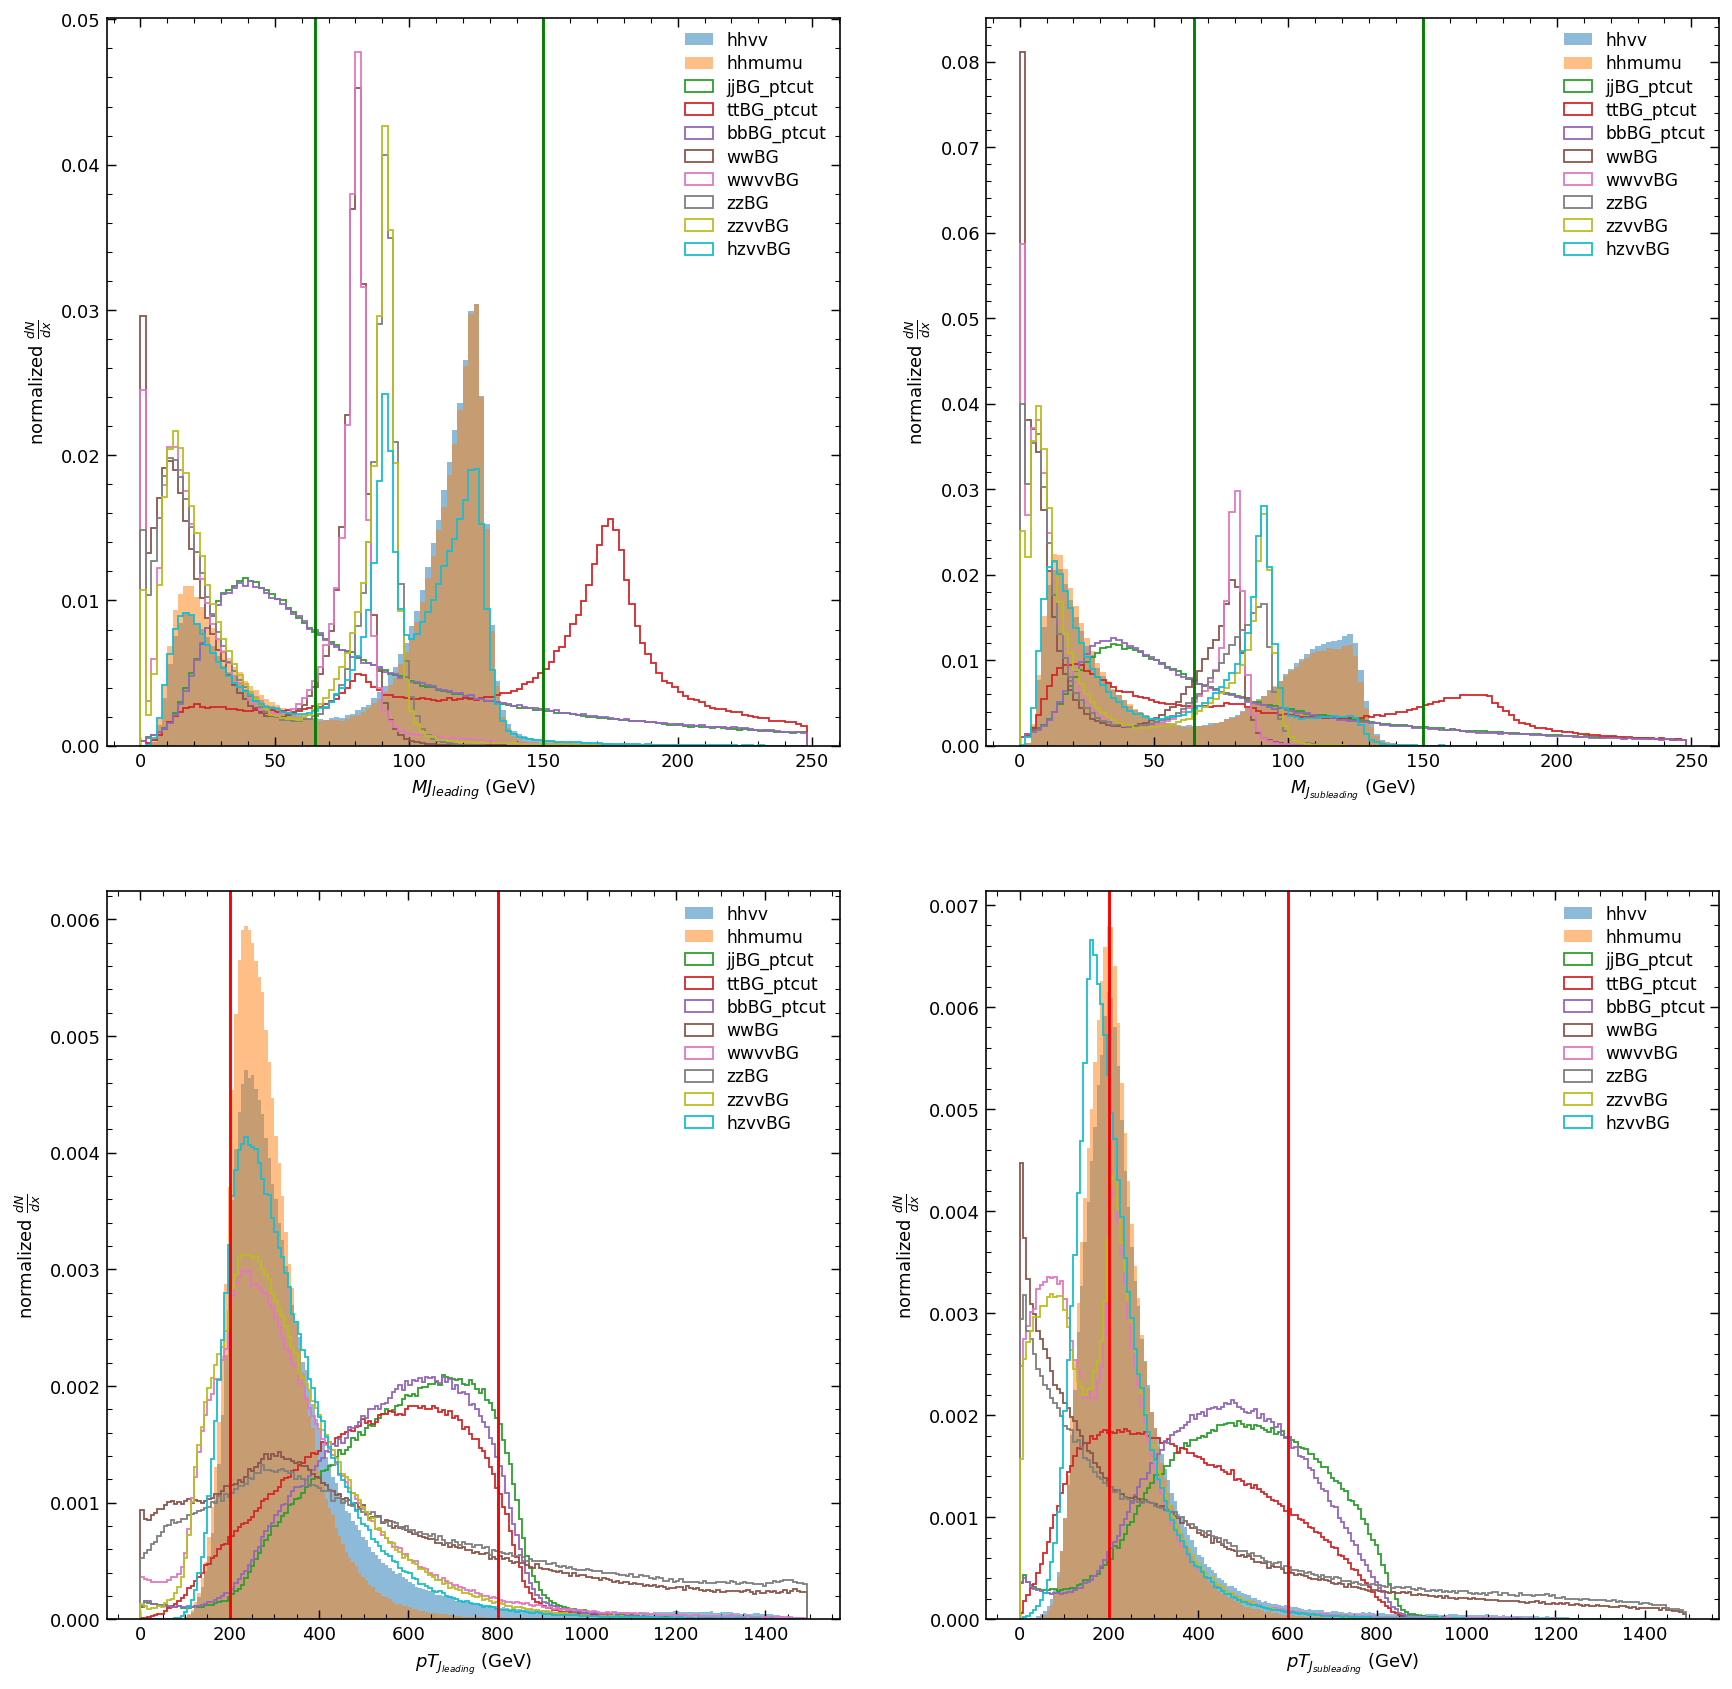

In [6]:
##### plot the histogram #####

fig = plt.figure(figsize=(16, 16))

fig.add_subplot(221)     ### plot leading jet mass
bins = np.arange(0,250,2)
for process in processes:
    plt.hist(m_J_leading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(65, color='g')
plt.axvline(150, color='g')
plt.xlabel(r"$M{J_{leading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(222)     ### plot subleading jet mass
bins = np.arange(0,250,2)
for process in processes:
    plt.hist(m_J_subleading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(65, color='g')
plt.axvline(150, color='g')
plt.xlabel(r"$M_{J_{subleading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(223)     ### plot leading jet PT
bins = np.arange(0,1500,7.5)
for process in processes:
    plt.hist(pt_J_leading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(200, color='r')
plt.axvline(800, color='r')
plt.xlabel(r"$pT_{J_{leading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(224)     ### plot subleading jet PT
bins = np.arange(0,1500,7.5)
for process in processes:
    plt.hist(pt_J_subleading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(200, color='r')
plt.axvline(600, color='r')
plt.xlabel(r"$pT_{J_{subleading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

plt.show()

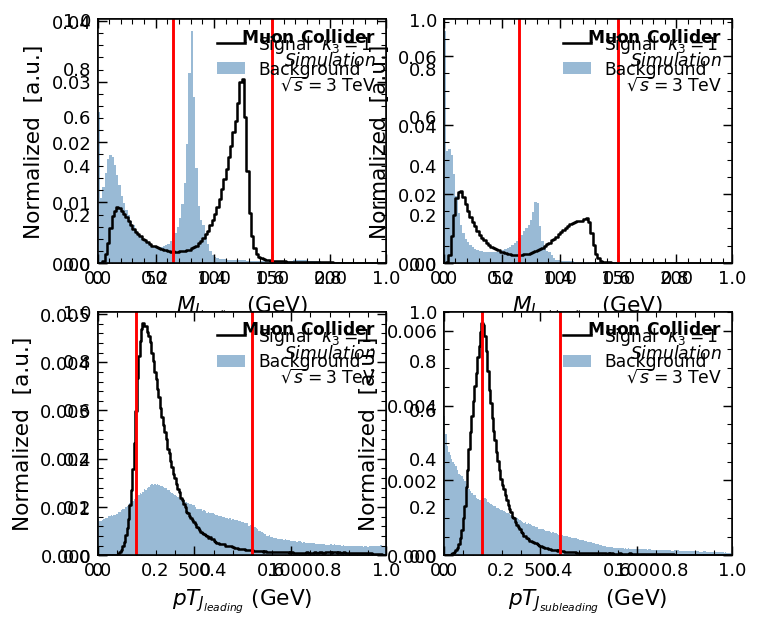

In [7]:
##### plot the histogram #####

fig, axes = plt.subplots(2, 2, figsize=(ps.FULL, ps.FULL * 0.85))

fig.add_subplot(221)     ### plot leading jet mass
sig_bg_plot(m_J_leading, bins=np.arange(0,250,2), xlabel=r"$M_{J_{leading}} ~\rm{(GeV)}$")
plt.axvline(65, color='r')
plt.axvline(150, color='r')

fig.add_subplot(222)     ### plot subleading jet mass
sig_bg_plot(m_J_subleading, bins=np.arange(0,250,2), xlabel=r"$M_{J_{subleading}} ~\rm{(GeV)}$")
plt.axvline(65, color='r')
plt.axvline(150, color='r')

fig.add_subplot(223)    ### plot leading jet PT
sig_bg_plot(pt_J_leading, bins=np.arange(0,1500,7.5), xlabel=r"$pT_{J_{leading}} ~\rm{(GeV)}$")
plt.axvline(200, color='r')
plt.axvline(800, color='r')

fig.add_subplot(224)    ### plot subleading jet PT
sig_bg_plot(pt_J_subleading, bins=np.arange(0,1500,7.5), xlabel=r"$pT_{J_{subleading}} ~\rm{(GeV)}$")
plt.axvline(200, color='r')
plt.axvline(600, color='r')

plt.show()

saved /data/mucollider/two_boosted/generated_fig/3TeV_preselection_boosted.pdf


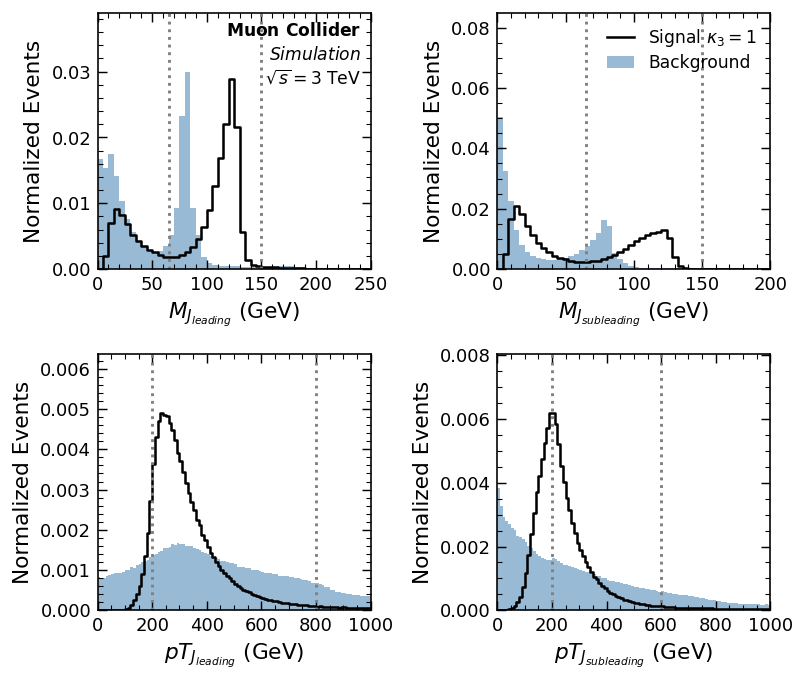

In [21]:

# Colours: signal = black step, background = blue filled step
COL_SIG = 'k'
COL_BG  = 'steelblue'

# ==========================================
# 2. 定義 PANELS 
# 格式: (panel_label, xlabel, feature_data, x-range, n_bins)
# ==========================================
PANELS = [
    (r"$M_{J_{leading}} ~\rm{(GeV)}$", m_J_leading, (0,250), 50),
    (r"$M_{J_{subleading}} ~\rm{(GeV)}$", m_J_subleading, (0,200), 50),
    (r"$pT_{J_{leading}} ~\rm{(GeV)}$", pt_J_leading, (0,1000), 100),
    (r"$pT_{J_{subleading}} ~\rm{(GeV)}$", pt_J_subleading, (0,1000), 100),
]

# ==========================================
# 3. 建立畫布與迴圈繪圖
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(ps.FULL, ps.FULL * 0.85))

for (xlbl, current_feature, (lo, hi), nb), ax in zip(PANELS, axes.flat):
    
    # -- A. 處理資料與權重 (Weight) --
    sig_Xsection = Xsection[0:2]
    bg_Xsection = Xsection[2:]
    
    # 根據當前 feature 的長度產生對應的 weight 陣列
    sig_weight = [np.full(len(current_feature[i]), sig_Xsection[i]) for i in range(len(sig_Xsection))]
    bg_weight = [np.full(len(current_feature[2+i]), bg_Xsection[i]) for i in range(len(bg_Xsection))]
    
    # 將多個 process 攤平合併
    sig_data_total = np.concatenate(current_feature[0:2])
    sig_weight_total = np.concatenate(sig_weight)
    
    bg_data_total = np.concatenate(current_feature[2:])
    bg_weight_total = np.concatenate(bg_weight)
    
    # -- B. 計算 Histogram --
    edges = np.linspace(lo, hi, nb + 1)
    
    h_bg, _  = np.histogram(bg_data_total,  bins=edges, weights=bg_weight_total, density=True)
    h_sig, _ = np.histogram(sig_data_total, bins=edges, weights=sig_weight_total, density=True)

    # -- C. 繪圖 --
    # Background — filled step; zorder lower so signal stays on top
    ax.fill_between(edges, np.r_[h_bg, h_bg[-1]], step='post',
                    color=COL_BG, alpha=0.55, linewidth=0,
                    label='Background', zorder=1)
    
    # Signal — black step
    ax.step(edges, np.r_[h_sig, h_sig[-1]], where='post',
            color=COL_SIG, lw=1.4, label=r'Signal $\kappa_3 = 1$', zorder=2)

    # -- D. 設定座標軸與標籤 --
    ax.set_xlabel(xlbl)
    ax.set_ylabel('Normalized Events')
    ax.set_xlim(lo, hi)
    top = max(h_bg.max(initial=0.0), h_sig.max(initial=0.0))
    ax.set_ylim(0, top * 1.30)
    
    if current_feature==m_J_leading or current_feature==m_J_subleading:
        ax.axvline(65, color='gray', linestyle=':')
        ax.axvline(150, color='gray', linestyle=':')
    elif current_feature==pt_J_leading:
        ax.axvline(200, color='gray', linestyle=':')
        ax.axvline(800, color='gray', linestyle=':')
    elif current_feature==pt_J_subleading:
        ax.axvline(200, color='gray', linestyle=':')
        ax.axvline(600, color='gray', linestyle=':')

# ==========================================
# 4. 全局設定與顯示
# ==========================================
# HEP tag + legend in panel (a) / panel (b)
axes[0, 1].set_ylim(0, axes[0, 1].get_ylim()[1] * 1.30)   # legend headroom
ps.hep_tag(axes[0, 0], [r'$\sqrt{s} = 3$ TeV'], loc='upper right', simulation=True)
axes[0, 1].legend(loc='upper right')

fig.tight_layout()

OUTPDF = "/data/mucollider/two_boosted/generated_fig/3TeV_preselection_boosted.pdf"
fig.savefig(OUTPDF, bbox_inches='tight')
print(f'saved {OUTPDF}')

plt.show()

In [9]:
########## Do some basic cuts ##########

##### leading jet pT selection #####

leading_low_pT_cut = 200   ### GeV
leading_high_pT_cut = 800   ### GeV
for process in processes:
    events[processes.index(process)] = pT_leading_selection(events[processes.index(process)], leading_low_pT_cut, leading_high_pT_cut)
print("\nAfter leading jet pT selection:")
count(events)

##### subleading jet pT selection #####

subleading_low_pT_cut = 200   ### GeV
subleading_high_pT_cut = 600   ### GeV
for process in processes:
    events[processes.index(process)] = pT_subleading_selection(events[processes.index(process)], subleading_low_pT_cut, subleading_high_pT_cut)
print("\nAfter subleading jet pT selection:")
count(events)

##### leading jet mass selection #####

leading_low_mass_cut = 65
leading_high_mass_cut = 150
for process in processes:
    events[processes.index(process)] = mass_leading_selection(events[processes.index(process)], leading_low_mass_cut, leading_high_mass_cut)
print("\nAfter leading jet mass selection:")
count(events)

##### subleading jet mass selection #####

subleading_low_mass_cut = 65
subleading_high_mass_cut = 150
for process in processes:
    events[processes.index(process)] = mass_subleading_selection(events[processes.index(process)], subleading_low_mass_cut, subleading_high_mass_cut)
print("\nAfter subleading jet mass selection:")
count(events)


After leading jet pT selection:
There are 438930 hhvv events. Corresponding cross section: 0.016845076524420126 (fb)
There are 448736 hhmumu events. Corresponding cross section: 0.0014484429842038077 (fb)
There are 432154 jjBG_ptcut events. Corresponding cross section: 11.6287455552 (fb)
There are 440935 ttBG_ptcut events. Corresponding cross section: 3.901128319 (fb)
There are 444726 bbBG_ptcut events. Corresponding cross section: 2.0685095712000003 (fb)
There are 267175 wwBG events. Corresponding cross section: 80.536323605 (fb)
There are 354995 wwvvBG events. Corresponding cross section: 8.6839373893 (fb)
There are 257642 zzBG events. Corresponding cross section: 4.9555377564 (fb)
There are 365785 zzvvBG events. Corresponding cross section: 4.73284529452 (fb)
There are 432324 hzvvBG events. Corresponding cross section: 0.6426550178619218 (fb)

After subleading jet pT selection:
There are 280114 hhvv events. Corresponding cross section: 0.010750100848794613 (fb)
There are 281348 hhm

In [10]:
########## visualization of other kinematics ##########

missET = []
X_HH = []
M_JJ = []
pT_JJ = []
dEta_JJ = []
BTag_leading = []
BTag_subleading = []

##### calculate kinematics #####

for process in processes:
    tmp_met = []
    tmp_X_HH = []
    tmp_M_JJ = []
    tmp_pT_JJ = []
    tmp_dEta_JJ = []
    tmp_Btag_0 = []
    tmp_Btag_1 = []
    for i in range(len(events[processes.index(process)])):
        tmp_met.append(events[processes.index(process)][i][features.index("MissingET.MET")][0])
        tmp_X_HH.append(calculate_X_HH(events[processes.index(process)][i]))
        tmp_M_JJ.append(calculate_M_JJ(events[processes.index(process)][i]))
        tmp_pT_JJ.append(calculate_pT_JJ(events[processes.index(process)][i]))
        tmp_dEta_JJ.append(calculate_dEta_JJ(events[processes.index(process)][i]))
        tmp_Btag_0.append(events[processes.index(process)][i][features.index("VLCjetR10N2.BTag")][0])
        tmp_Btag_1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.BTag")][1])
    missET.append(tmp_met)
    X_HH.append(tmp_X_HH)
    M_JJ.append(tmp_M_JJ)
    pT_JJ.append(tmp_pT_JJ)
    dEta_JJ.append(tmp_dEta_JJ)
    BTag_leading.append(tmp_Btag_0)
    BTag_subleading.append(tmp_Btag_1)
    print("Time:{:^8.4f}(s)".format(time.time()-t1))
    
del tmp_met, tmp_X_HH, tmp_M_JJ, tmp_pT_JJ, tmp_dEta_JJ, tmp_Btag_0, tmp_Btag_1

Time:249.7747(s)
Time:267.3046(s)
Time:271.7739(s)
Time:276.2198(s)
Time:281.0959(s)
Time:287.3510(s)
Time:299.6424(s)
Time:307.3404(s)
Time:322.2483(s)
Time:338.5904(s)


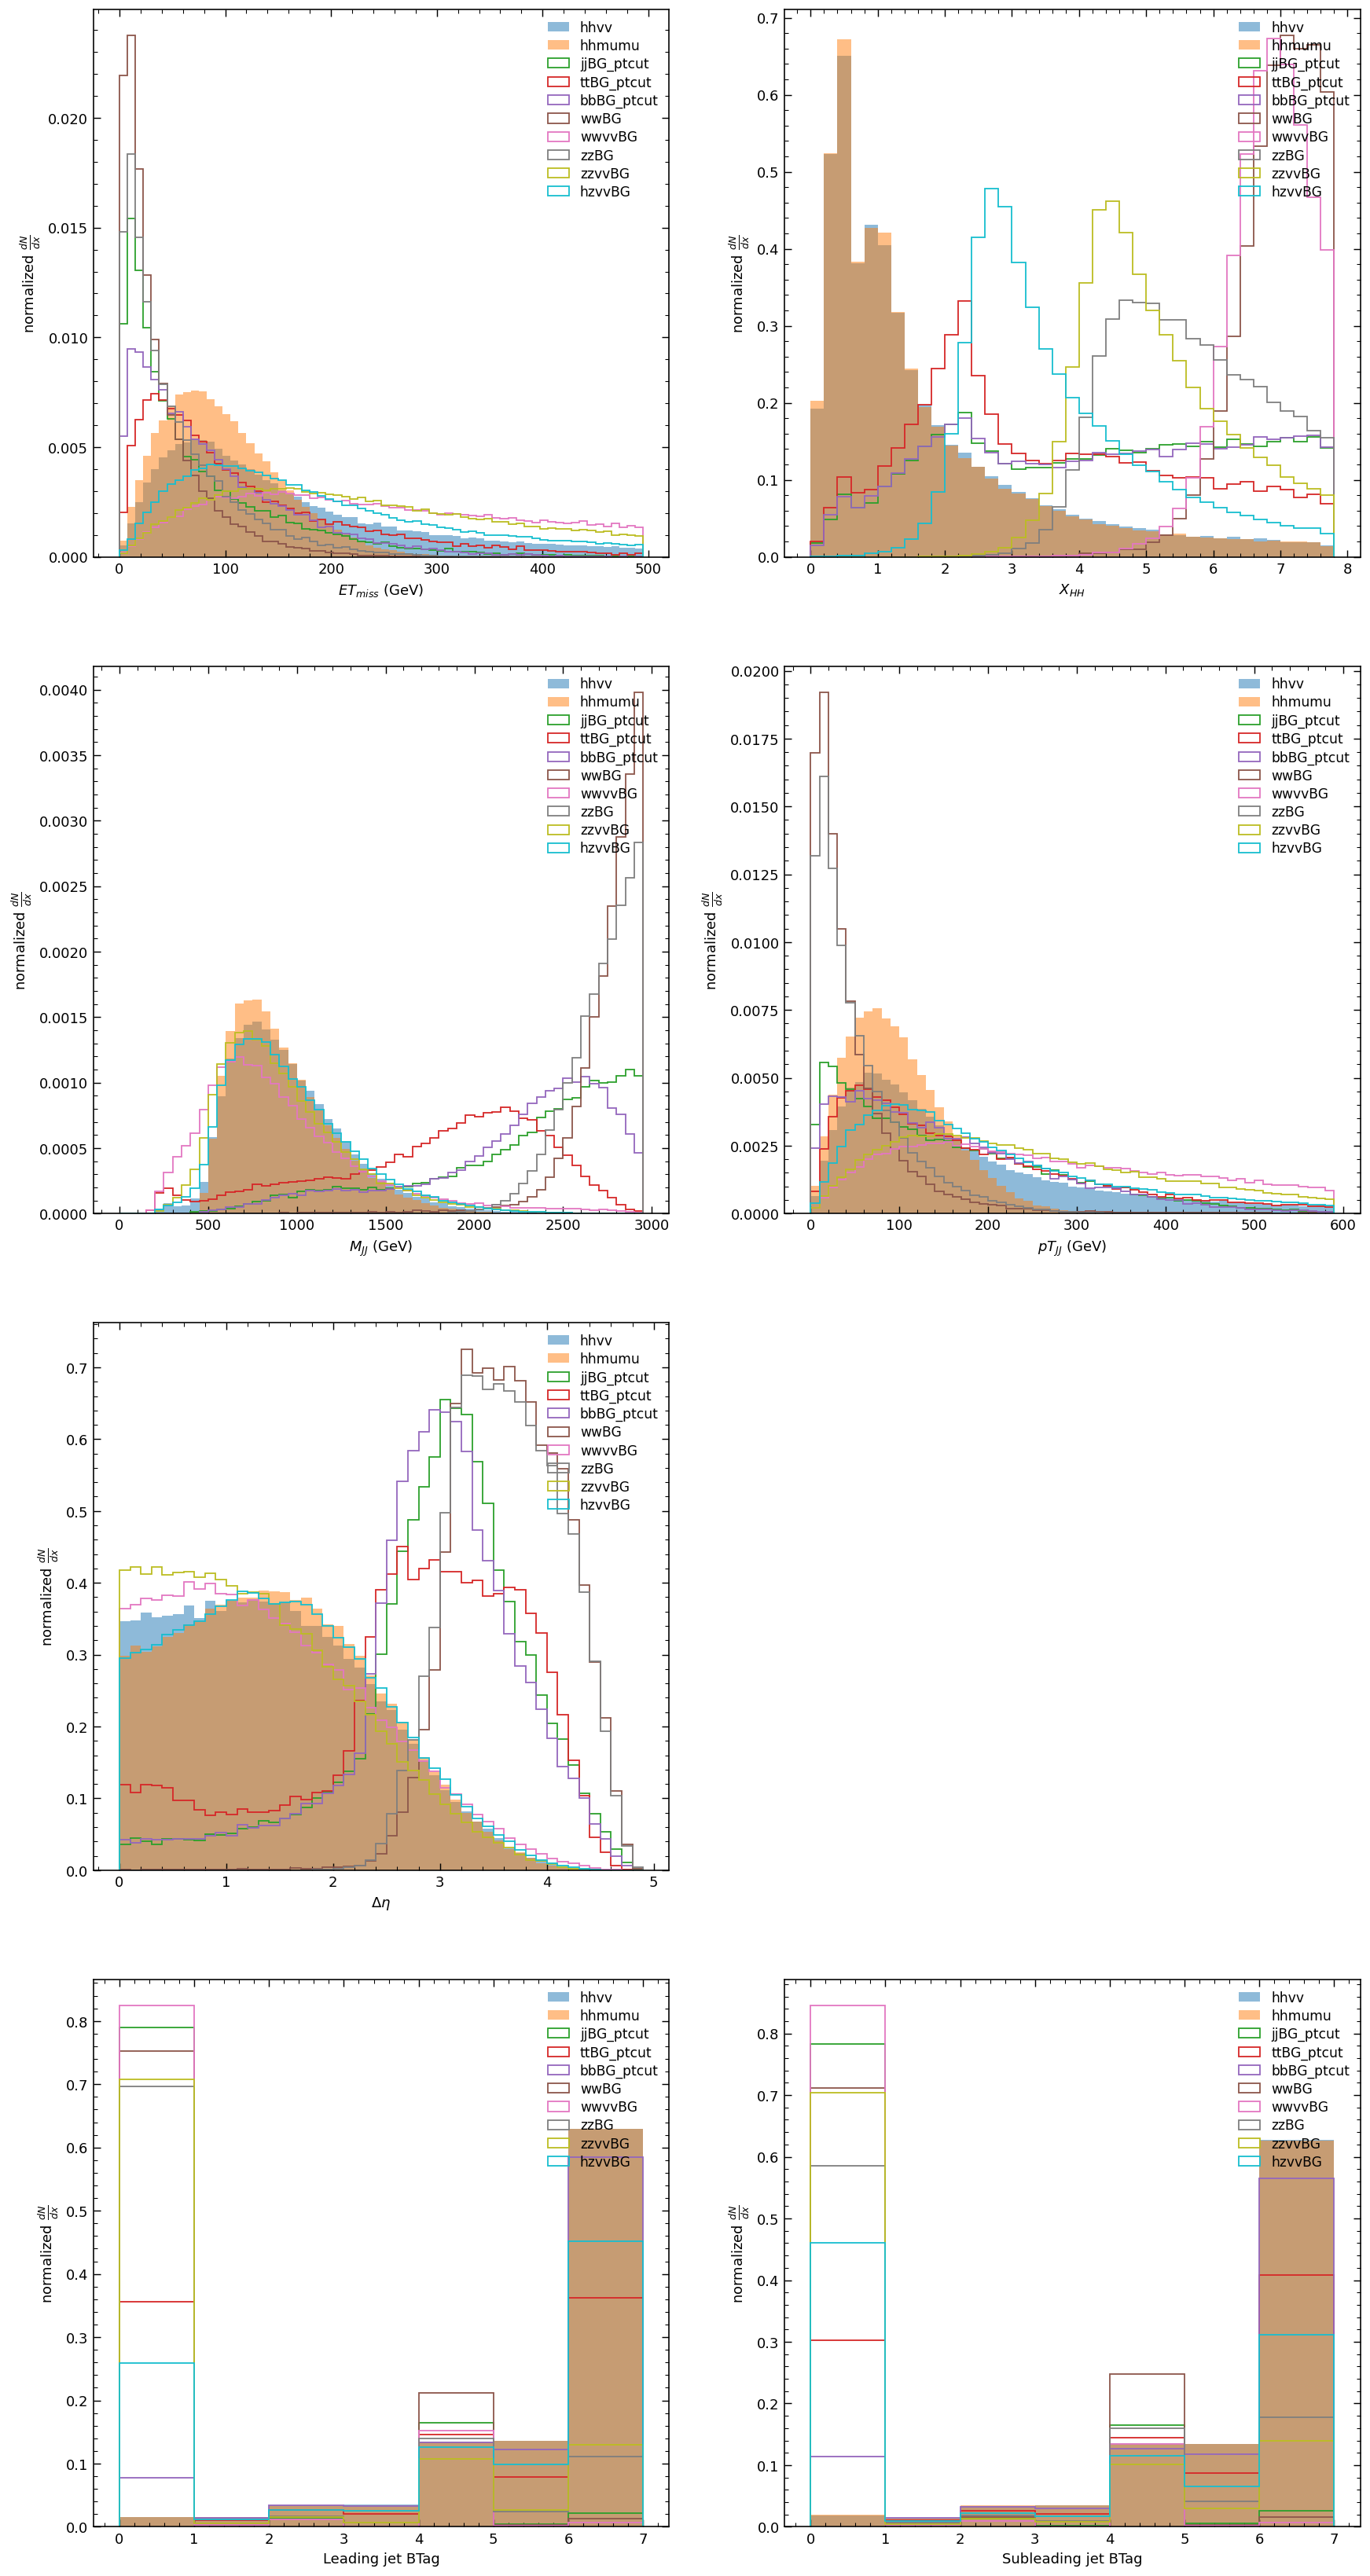

In [11]:
##### plot the histogram #####

fig = plt.figure(figsize=(16, 32))

fig.add_subplot(421)     ### plot MET
bins = np.arange(0,500,7.5)
for process in processes:
    plt.hist(missET[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$ET_{miss} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(422)     ### plot X_HH
bins = np.arange(0,8,0.2)
for process in processes:
    plt.hist(X_HH[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$X_{HH}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(423)     ### plot M_JJ
bins = np.arange(0,3000,50)
for process in processes:
    plt.hist(M_JJ[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$M_{JJ}~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(424)     ### plot pT_JJ
bins = np.arange(0,600,10)
for process in processes:
    plt.hist(pT_JJ[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$pT_{JJ}~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(425)     ### plot dEta_JJ
bins = np.arange(0,5,0.1)
for process in processes:
    plt.hist(dEta_JJ[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$\Delta \eta$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(427)     ### plot BTag of leading jet
bins = np.arange(0,8,1)
for process in processes:
    plt.hist(BTag_leading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"Leading jet BTag", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(428)     ### plot BTag of subleading jet
bins = np.arange(0,8,1)
for process in processes:
    plt.hist(BTag_subleading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"Subleading jet BTag", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

plt.show()

saved /data/mucollider/two_boosted/generated_fig/fig_boosted_kin.pdf


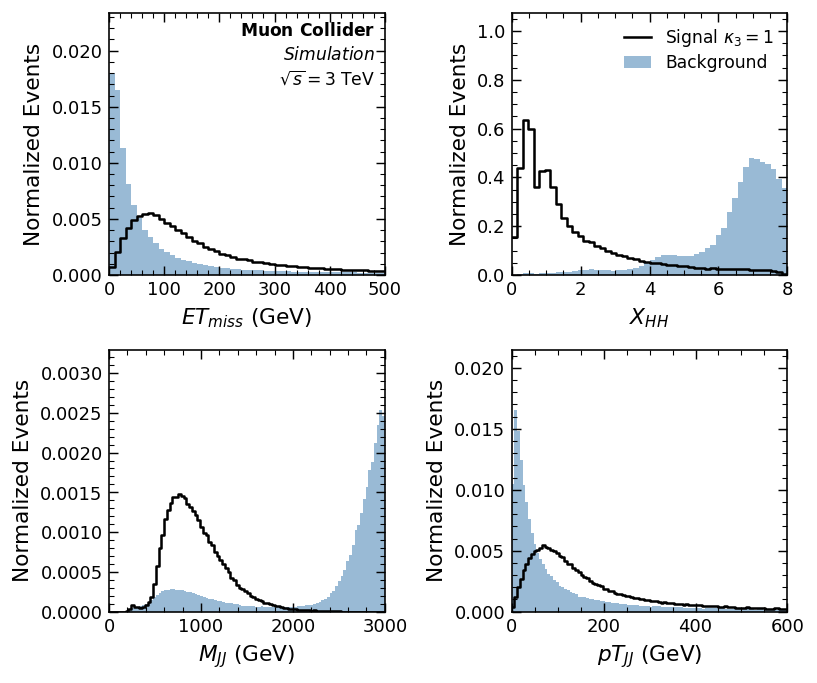

In [20]:
##### plot the histogram #####


# Colours: signal = black step, background = blue filled step
COL_SIG = 'k'
COL_BG  = 'steelblue'

# ==========================================
# 2. 定義 PANELS 
# 格式: (panel_label, xlabel, feature_data, x-range, n_bins)
# ==========================================
PANELS = [
    (r"$ET_{miss} ~\rm{(GeV)}$", missET, (0,500), 50),
    (r"$X_{HH}$", X_HH, (0,8), 50),
    (r"$M_{JJ}~\rm{(GeV)}$", M_JJ, (0,3000), 100),
    (r"$pT_{JJ}~\rm{(GeV)}$", pT_JJ, (0,600), 100),
]

# ==========================================
# 3. 建立畫布與迴圈繪圖
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(ps.FULL, ps.FULL*0.85))

for (xlbl, current_feature, (lo, hi), nb), ax in zip(PANELS, axes.flat):
    
    # -- A. 處理資料與權重 (Weight) --
    sig_Xsection = Xsection[0:2]
    bg_Xsection = Xsection[2:]
    
    # 根據當前 feature 的長度產生對應的 weight 陣列
    sig_weight = [np.full(len(current_feature[i]), sig_Xsection[i]) for i in range(len(sig_Xsection))]
    bg_weight = [np.full(len(current_feature[2+i]), bg_Xsection[i]) for i in range(len(bg_Xsection))]
    
    # 將多個 process 攤平合併
    sig_data_total = np.concatenate(current_feature[0:2])
    sig_weight_total = np.concatenate(sig_weight)
    
    bg_data_total = np.concatenate(current_feature[2:])
    bg_weight_total = np.concatenate(bg_weight)
    
    # -- B. 計算 Histogram --
    edges = np.linspace(lo, hi, nb + 1)
    
    h_bg, _  = np.histogram(bg_data_total,  bins=edges, weights=bg_weight_total, density=True)
    h_sig, _ = np.histogram(sig_data_total, bins=edges, weights=sig_weight_total, density=True)

    # -- C. 繪圖 --
    # Background — filled step; zorder lower so signal stays on top
    ax.fill_between(edges, np.r_[h_bg, h_bg[-1]], step='post',
                    color=COL_BG, alpha=0.55, linewidth=0,
                    label='Background', zorder=1)
    
    # Signal — black step
    ax.step(edges, np.r_[h_sig, h_sig[-1]], where='post',
            color=COL_SIG, lw=1.4, label=r'Signal $\kappa_3 = 1$', zorder=2)

    # -- D. 設定座標軸與標籤 --
    ax.set_xlabel(xlbl)
    ax.set_ylabel('Normalized Events')
    ax.set_xlim(lo, hi)
    top = max(h_bg.max(initial=0.0), h_sig.max(initial=0.0))
    ax.set_ylim(0, top * 1.30)

# ==========================================
# 4. 全局設定與顯示
# ==========================================
# HEP tag + legend in panel (a) / panel (b)
axes[0, 1].set_ylim(0, axes[0, 1].get_ylim()[1] * 1.30)   # legend headroom
ps.hep_tag(axes[0, 0], [r'$\sqrt{s} = 3$ TeV'], loc='upper right', simulation=True)
axes[0, 1].legend(loc='upper right')

fig.tight_layout()

OUTPDF = "/data/mucollider/two_boosted/generated_fig/fig_boosted_kin.pdf"
fig.savefig(OUTPDF, bbox_inches='tight')
print(f'saved {OUTPDF}')

# 在 Notebook 裡直接顯示 (取代原本的 savefig)
plt.show()

In [13]:
# data_file[processes=="hhvv"]["Delphes;1"].show()

##### show the event #####

events[0][4]

array([2, array([286.09225, 270.69412], dtype=float32),
       array([-0.13884254, -0.4202656 ], dtype=float32),
       array([-0.99211746,  1.8699918 ], dtype=float32),
       array([127.24728,  96.65695], dtype=float32),
       array([83.73089], dtype=float32), array([5, 0], dtype=uint32)],
      dtype=object)

In [14]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:368.1941(s)
